# Data Visualization with Matplotlib & Seaborn - Exercise Solutions Guide 📊✅

Reference solutions for **Lecture 7: Data Visualization with Matplotlib & Seaborn - Practice & Exercise Notebook**.

## Setup: Import Plotting Libraries & Configure Display

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
import pandas as pd
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set display settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Matplotlib version: 3.10.6
Seaborn version: 0.13.2


## Exercise 1: Figure Architecture & Dual Line Chart 📈

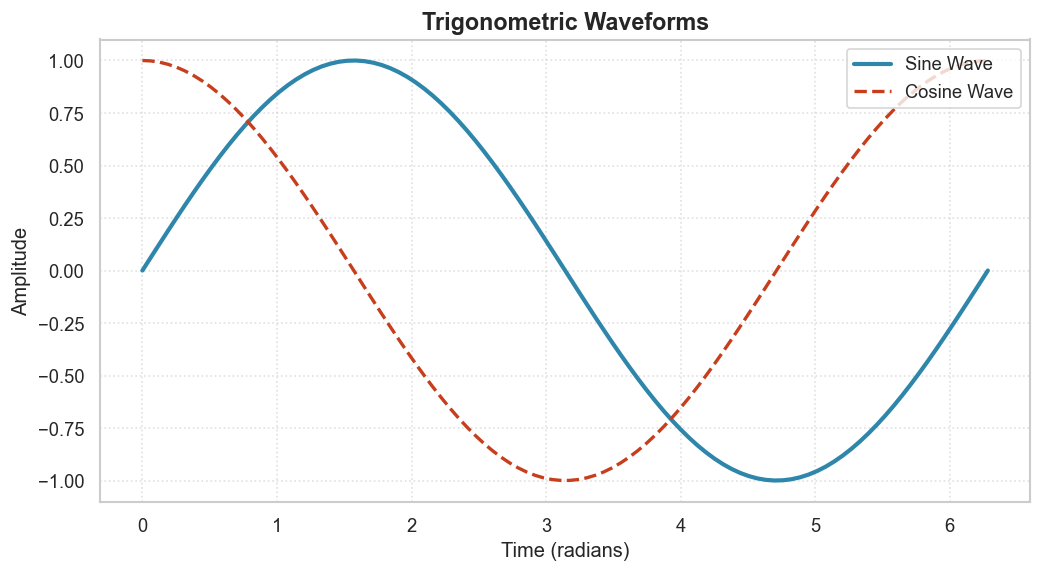

In [2]:
# Sample Data
x = np.linspace(0, 2 * np.pi, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# SOLUTION 1
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(x, y1, color='#2E86AB', linewidth=2.5, label='Sine Wave')
ax1.plot(x, y2, color='#C73E1D', linestyle='--', linewidth=2.0, label='Cosine Wave')
ax1.set_title('Trigonometric Waveforms', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time (radians)')
ax1.set_ylabel('Amplitude')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [3]:
# VERIFICATION TEST 1
assert fig1 is not None and ax1 is not None, "fig1 and ax1 must be defined"
assert len(ax1.lines) == 2, f"Expected 2 plotted lines, got {len(ax1.lines)}"
assert ax1.get_title() == 'Trigonometric Waveforms', f"Title mismatch: got '{ax1.get_title()}'"
assert ax1.get_xlabel() == 'Time (radians)', f"X-label mismatch: got '{ax1.get_xlabel()}'"
assert ax1.get_ylabel() == 'Amplitude', f"Y-label mismatch: got '{ax1.get_ylabel()}'"
assert ax1.get_legend() is not None, "Legend is missing"

print("✅ Exercise 1 Passed!")

✅ Exercise 1 Passed!


## Exercise 2: Multi-Subplot Line Comparisons with Shaded Confidence Bands 📉

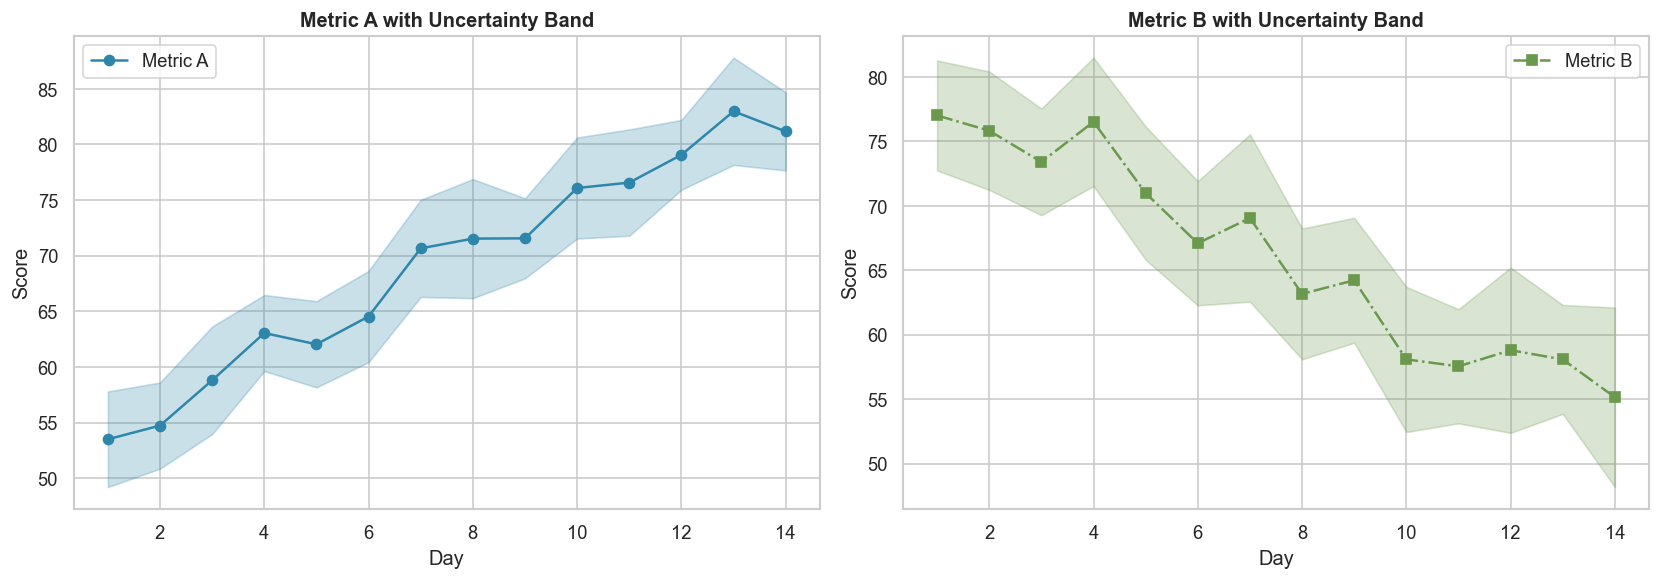

In [4]:
np.random.seed(42)
days = np.arange(1, 15)
trend_a = 50 + 2.5 * days + np.random.normal(0, 2, 14)
std_a = np.random.uniform(3, 6, 14)

trend_b = 80 - 1.8 * days + np.random.normal(0, 2, 14)
std_b = np.random.uniform(4, 7, 14)

# SOLUTION 2
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Left
axes2[0].plot(days, trend_a, marker='o', color='#2E86AB', label='Metric A')
axes2[0].fill_between(days, trend_a - std_a, trend_a + std_a, color='#2E86AB', alpha=0.25)
axes2[0].set_title('Metric A with Uncertainty Band', fontweight='bold')
axes2[0].set_xlabel('Day')
axes2[0].set_ylabel('Score')
axes2[0].legend()

# Right
axes2[1].plot(days, trend_b, marker='s', color='#6A994E', linestyle='-.', label='Metric B')
axes2[1].fill_between(days, trend_b - std_b, trend_b + std_b, color='#6A994E', alpha=0.25)
axes2[1].set_title('Metric B with Uncertainty Band', fontweight='bold')
axes2[1].set_xlabel('Day')
axes2[1].set_ylabel('Score')
axes2[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# VERIFICATION TEST 2
assert fig2 is not None and axes2 is not None, "fig2 and axes2 must be defined"
assert len(axes2) == 2, "Expected 2 subplots in axes2"
assert len(axes2[0].lines) >= 1 and len(axes2[1].lines) >= 1, "Lines missing in subplots"
assert len(axes2[0].collections) >= 1, "fill_between collection missing in left subplot"
assert len(axes2[1].collections) >= 1, "fill_between collection missing in right subplot"

print("✅ Exercise 2 Passed!")

✅ Exercise 2 Passed!


## Exercise 3: Categorical Vertical & Horizontal Bar Charts with Exact Labels 📊

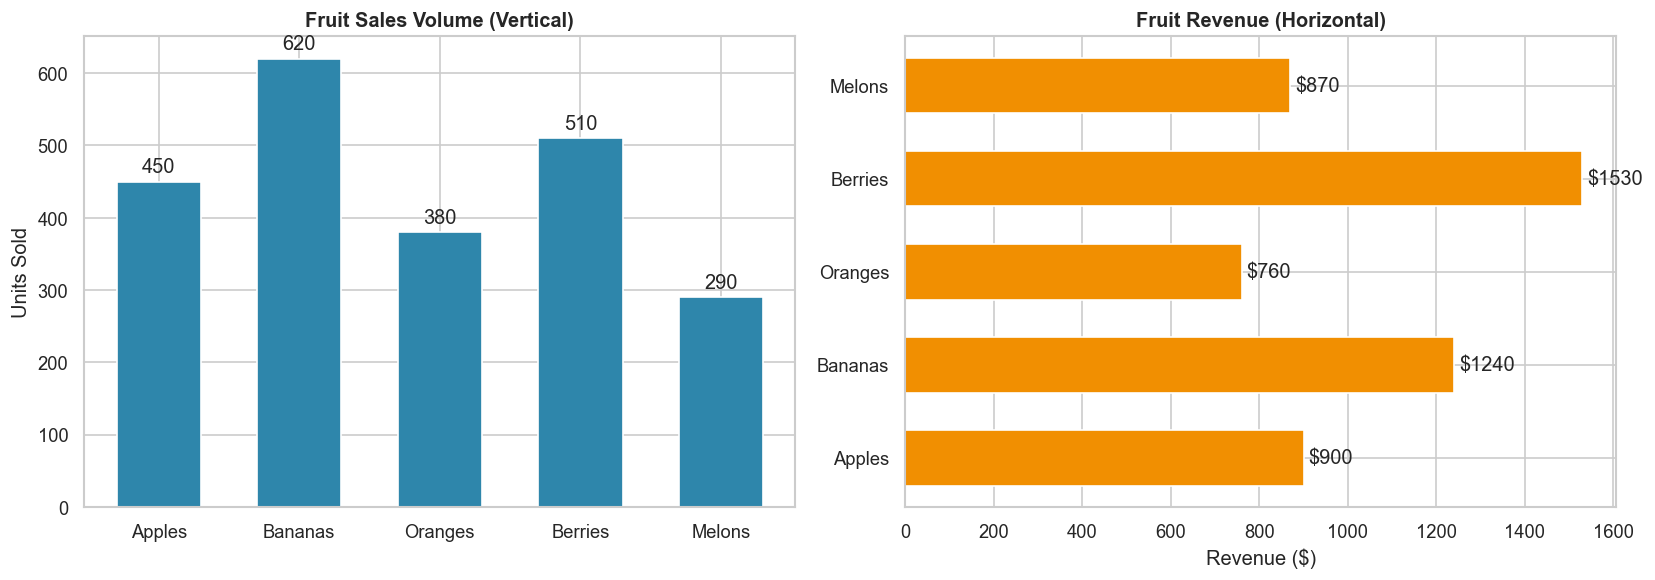

In [6]:
fruits = ['Apples', 'Bananas', 'Oranges', 'Berries', 'Melons']
sales_2025 = [450, 620, 380, 510, 290]
revenue_2025 = [900, 1240, 760, 1530, 870]

# SOLUTION 3
fig3, (ax3_v, ax3_h) = plt.subplots(1, 2, figsize=(14, 5))

# Vertical
bars_v = ax3_v.bar(fruits, sales_2025, color='#2E86AB', width=0.6)
ax3_v.bar_label(bars_v, padding=3)
ax3_v.set_title('Fruit Sales Volume (Vertical)', fontweight='bold')
ax3_v.set_ylabel('Units Sold')

# Horizontal
bars_h = ax3_h.barh(fruits, revenue_2025, color='#F18F01', height=0.6)
ax3_h.bar_label(bars_h, fmt='$%d', padding=3)
ax3_h.set_title('Fruit Revenue (Horizontal)', fontweight='bold')
ax3_h.set_xlabel('Revenue ($)')

plt.tight_layout()
plt.show()

In [7]:
# VERIFICATION TEST 3
assert fig3 is not None and ax3_v is not None and ax3_h is not None, "fig3 and axes must be defined"
assert len(ax3_v.patches) == 5, f"Expected 5 vertical bars, got {len(ax3_v.patches)}"
assert len(ax3_h.patches) == 5, f"Expected 5 horizontal bars, got {len(ax3_h.patches)}"
assert len(ax3_v.texts) == 5, "Bar labels missing on vertical bar chart"
assert len(ax3_h.texts) == 5, "Bar labels missing on horizontal bar chart"

print("✅ Exercise 3 Passed!")

✅ Exercise 3 Passed!


## Exercise 4: Grouped & Stacked Bar Charts 🧱

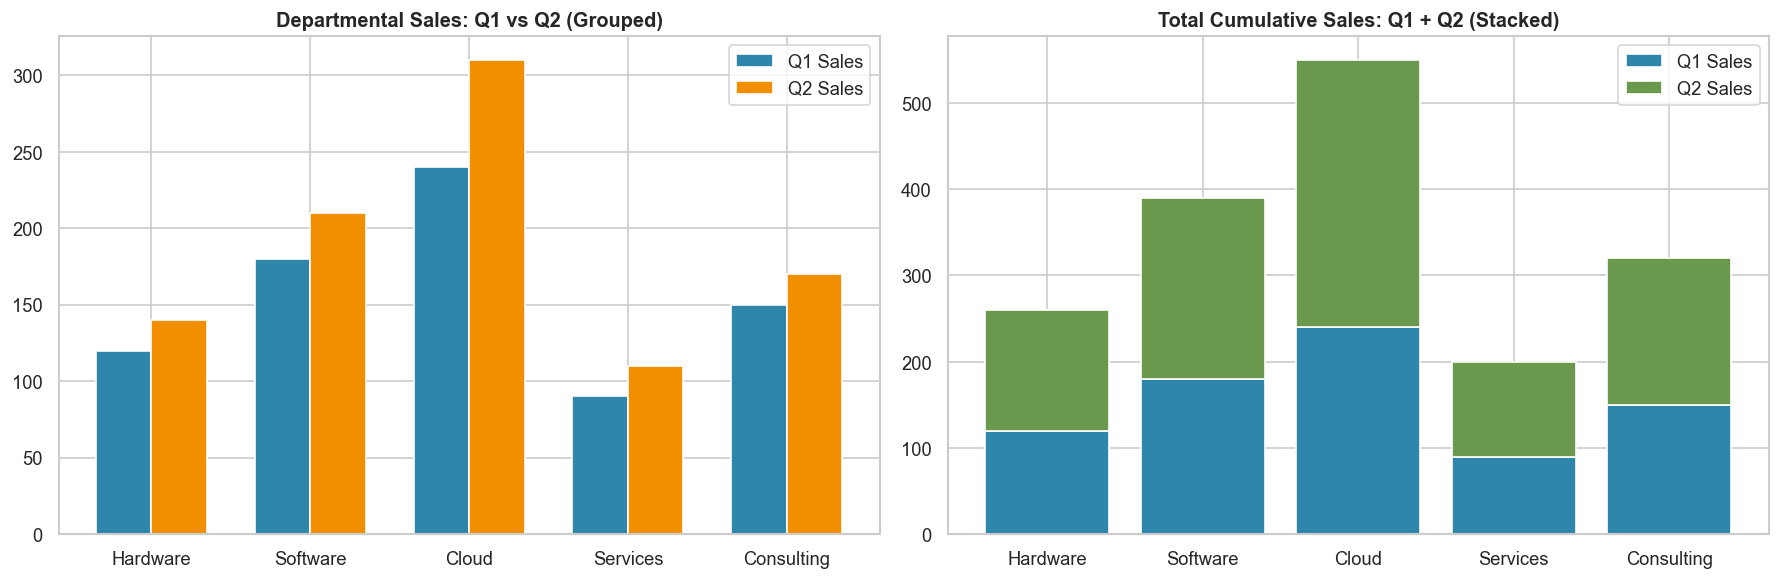

In [8]:
departments = ['Hardware', 'Software', 'Cloud', 'Services', 'Consulting']
Q1_Sales = np.array([120, 180, 240, 90, 150])
Q2_Sales = np.array([140, 210, 310, 110, 170])

# SOLUTION 4
fig4, (ax4_grp, ax4_stk) = plt.subplots(1, 2, figsize=(15, 5))

# Grouped
x_pos = np.arange(len(departments))
width = 0.35
ax4_grp.bar(x_pos - width/2, Q1_Sales, width=width, label='Q1 Sales', color='#2E86AB')
ax4_grp.bar(x_pos + width/2, Q2_Sales, width=width, label='Q2 Sales', color='#F18F01')
ax4_grp.set_xticks(x_pos)
ax4_grp.set_xticklabels(departments)
ax4_grp.set_title('Departmental Sales: Q1 vs Q2 (Grouped)', fontweight='bold')
ax4_grp.legend()

# Stacked
ax4_stk.bar(departments, Q1_Sales, label='Q1 Sales', color='#2E86AB')
ax4_stk.bar(departments, Q2_Sales, bottom=Q1_Sales, label='Q2 Sales', color='#6A994E')
ax4_stk.set_title('Total Cumulative Sales: Q1 + Q2 (Stacked)', fontweight='bold')
ax4_stk.legend()

plt.tight_layout()
plt.show()

In [9]:
# VERIFICATION TEST 4
assert fig4 is not None and ax4_grp is not None and ax4_stk is not None, "fig4 and axes must be defined"
assert len(ax4_grp.patches) == 10, f"Expected 10 patches in grouped bar chart, got {len(ax4_grp.patches)}"
assert len(ax4_stk.patches) == 10, f"Expected 10 patches in stacked bar chart, got {len(ax4_stk.patches)}"
assert ax4_grp.get_legend() is not None, "Legend missing on grouped bar chart"
assert ax4_stk.get_legend() is not None, "Legend missing on stacked bar chart"

print("✅ Exercise 4 Passed!")

✅ Exercise 4 Passed!


## Exercise 5: Multivariate Scatter Plot with Color, Size & Alpha Encodings 🔵🔴

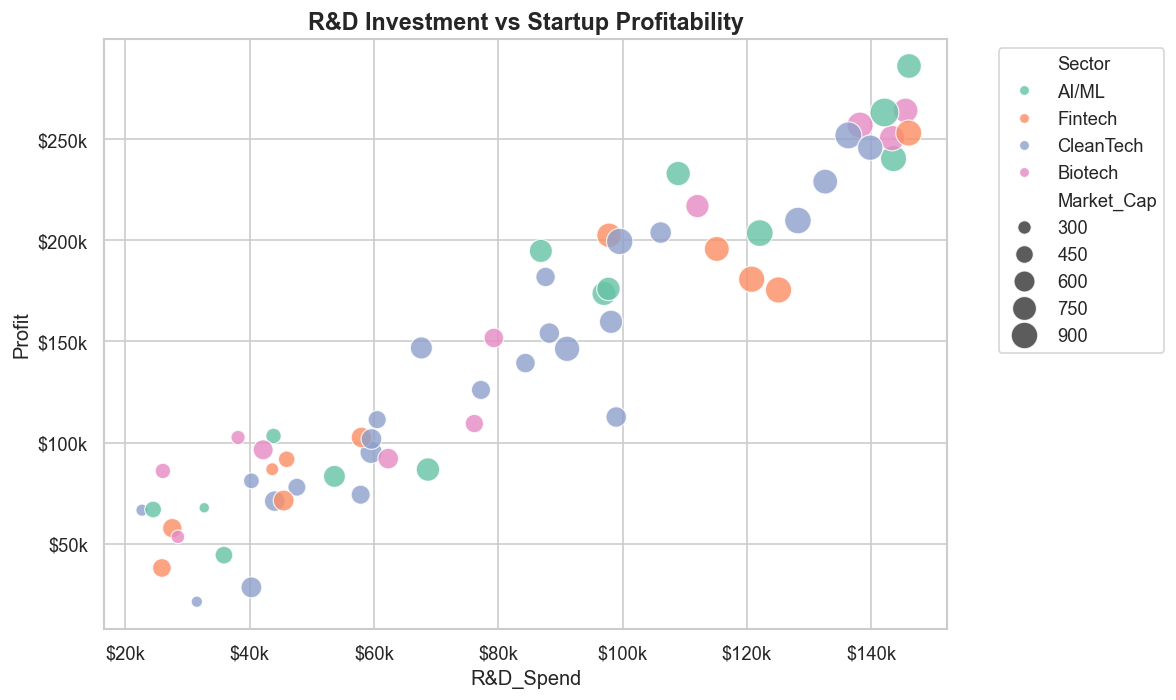

In [10]:
np.random.seed(42)
n_firms = 60
rnd = np.random.uniform(20, 150, n_firms)
profit = rnd * 1.8 + np.random.normal(0, 25, n_firms)
mkt_cap = rnd * 5 + np.random.uniform(50, 400, n_firms)
sector = np.random.choice(['AI/ML', 'Biotech', 'Fintech', 'CleanTech'], n_firms)

df_startup_data = pd.DataFrame({
    'R&D_Spend': rnd,
    'Profit': profit,
    'Market_Cap': mkt_cap,
    'Sector': sector
})

# SOLUTION 5
fig5, ax5 = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_startup_data,
    x='R&D_Spend',
    y='Profit',
    hue='Sector',
    size='Market_Cap',
    sizes=(40, 300),
    palette='Set2',
    alpha=0.8,
    ax=ax5
)
ax5.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${int(x)}k'))
ax5.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f'${int(y)}k'))
ax5.set_title('R&D Investment vs Startup Profitability', fontsize=14, fontweight='bold')
ax5.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [11]:
# VERIFICATION TEST 5
assert fig5 is not None and ax5 is not None, "fig5 and ax5 must be defined"
assert len(ax5.collections) >= 1, "Scatter point collection missing on ax5"
assert ax5.get_title() == 'R&D Investment vs Startup Profitability', "Title mismatch"
assert ax5.get_legend() is not None, "Legend is missing"

print("✅ Exercise 5 Passed!")

✅ Exercise 5 Passed!


## Exercise 6: Linear & Polynomial Regression Trendlines (`sns.regplot`) 📈

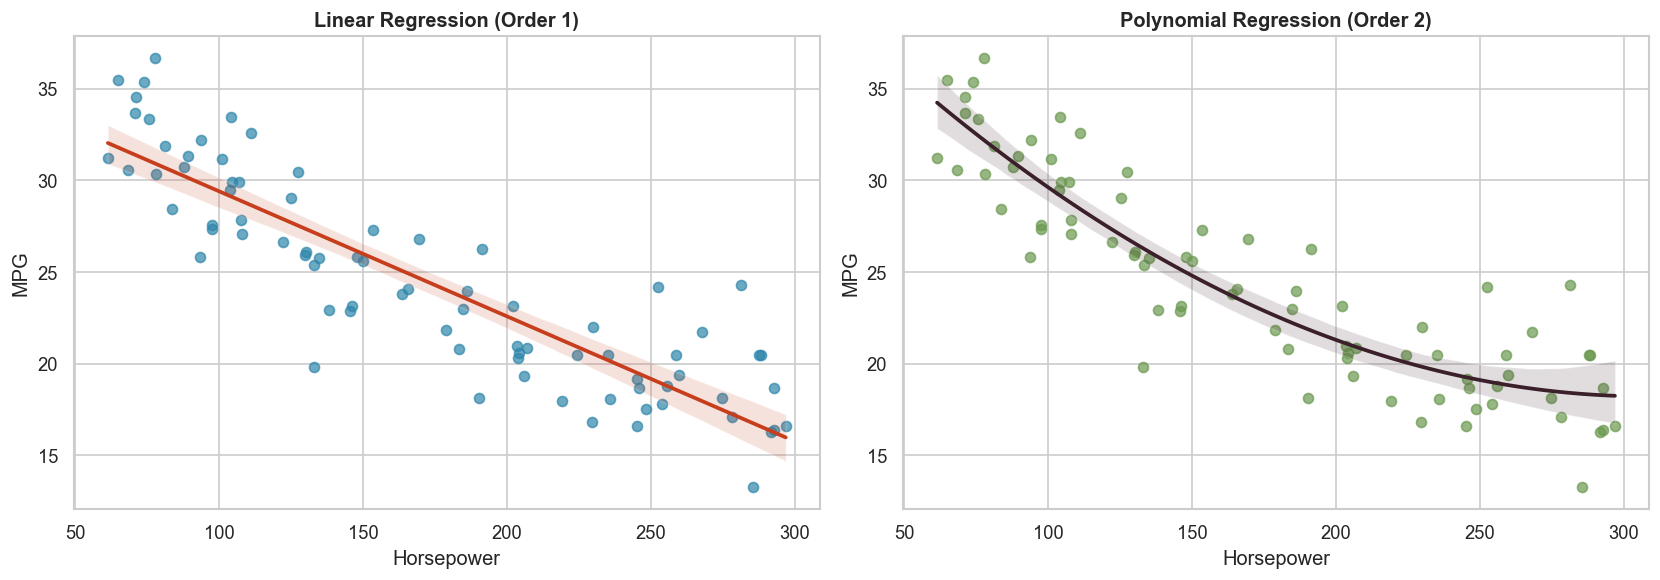

In [12]:
np.random.seed(42)
hp = np.random.uniform(60, 300, 80)
mpg = 45 - 0.18 * hp + 0.0003 * (hp**2) + np.random.normal(0, 2.5, 80)
df_car_efficiency = pd.DataFrame({'Horsepower': hp, 'MPG': mpg})

# SOLUTION 6
fig6, (ax6_lin, ax6_poly) = plt.subplots(1, 2, figsize=(14, 5))

# Linear
sns.regplot(
    data=df_car_efficiency,
    x='Horsepower',
    y='MPG',
    order=1,
    ci=95,
    scatter_kws={'color': '#2E86AB', 'alpha': 0.7},
    line_kws={'color': '#C73E1D'},
    ax=ax6_lin
)
ax6_lin.set_title('Linear Regression (Order 1)', fontweight='bold')

# Polynomial
sns.regplot(
    data=df_car_efficiency,
    x='Horsepower',
    y='MPG',
    order=2,
    ci=95,
    scatter_kws={'color': '#6A994E', 'alpha': 0.7},
    line_kws={'color': '#3B1F2B'},
    ax=ax6_poly
)
ax6_poly.set_title('Polynomial Regression (Order 2)', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# VERIFICATION TEST 6
assert fig6 is not None and ax6_lin is not None and ax6_poly is not None, "fig6 and axes must be defined"
assert len(ax6_lin.collections) >= 2, "Scatter points or CI band missing on linear plot"
assert len(ax6_poly.collections) >= 2, "Scatter points or CI band missing on polynomial plot"
assert len(ax6_lin.lines) == 1 and len(ax6_poly.lines) == 1, "Regression line missing"

print("✅ Exercise 6 Passed!")

✅ Exercise 6 Passed!


## Exercise 7: Distribution Analysis with Histograms, KDE & ECDF 🌊

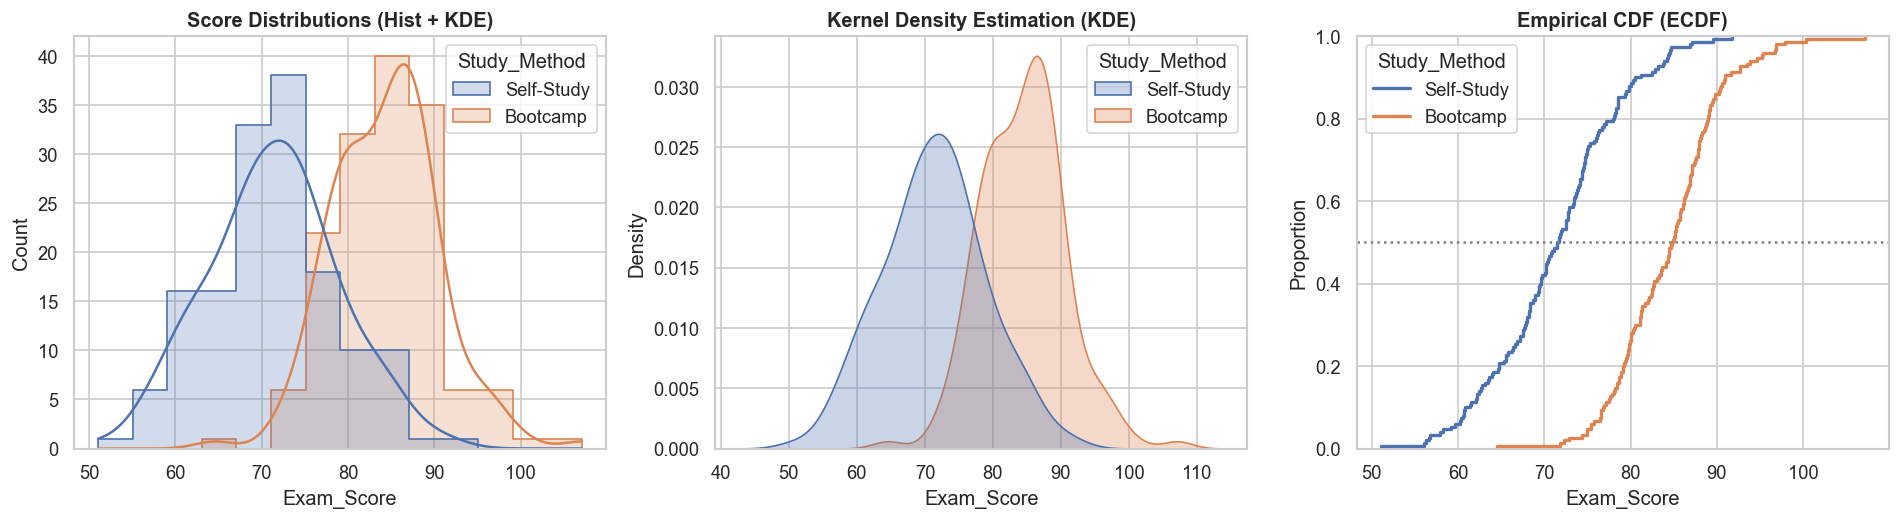

In [14]:
np.random.seed(42)
n_students = 150
method_a = np.random.normal(loc=72, scale=8, size=n_students)
method_b = np.random.normal(loc=84, scale=6, size=n_students)

df_exam_scores = pd.DataFrame({
    'Exam_Score': np.concatenate([method_a, method_b]),
    'Study_Method': ['Self-Study'] * n_students + ['Bootcamp'] * n_students
})

# SOLUTION 7
fig7, axes7 = plt.subplots(1, 3, figsize=(16, 4.5))

# Hist + KDE
sns.histplot(data=df_exam_scores, x='Exam_Score', hue='Study_Method', kde=True, element='step', ax=axes7[0])
axes7[0].set_title('Score Distributions (Hist + KDE)', fontweight='bold')

# KDE
sns.kdeplot(data=df_exam_scores, x='Exam_Score', hue='Study_Method', fill=True, alpha=0.3, ax=axes7[1])
axes7[1].set_title('Kernel Density Estimation (KDE)', fontweight='bold')

# ECDF
sns.ecdfplot(data=df_exam_scores, x='Exam_Score', hue='Study_Method', linewidth=2, ax=axes7[2])
axes7[2].axhline(0.5, color='gray', linestyle=':')
axes7[2].set_title('Empirical CDF (ECDF)', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# VERIFICATION TEST 7
assert fig7 is not None and axes7 is not None, "fig7 and axes7 must be defined"
assert len(axes7) == 3, f"Expected 3 subplots, got {len(axes7)}"
assert axes7[0].get_title() == 'Score Distributions (Hist + KDE)', "Subplot 1 title mismatch"
assert axes7[1].get_title() == 'Kernel Density Estimation (KDE)', "Subplot 2 title mismatch"
assert axes7[2].get_title() == 'Empirical CDF (ECDF)', "Subplot 3 title mismatch"

print("✅ Exercise 7 Passed!")

✅ Exercise 7 Passed!


## Exercise 8: Statistical Box Plots & Split Violin Plots 🎻📦

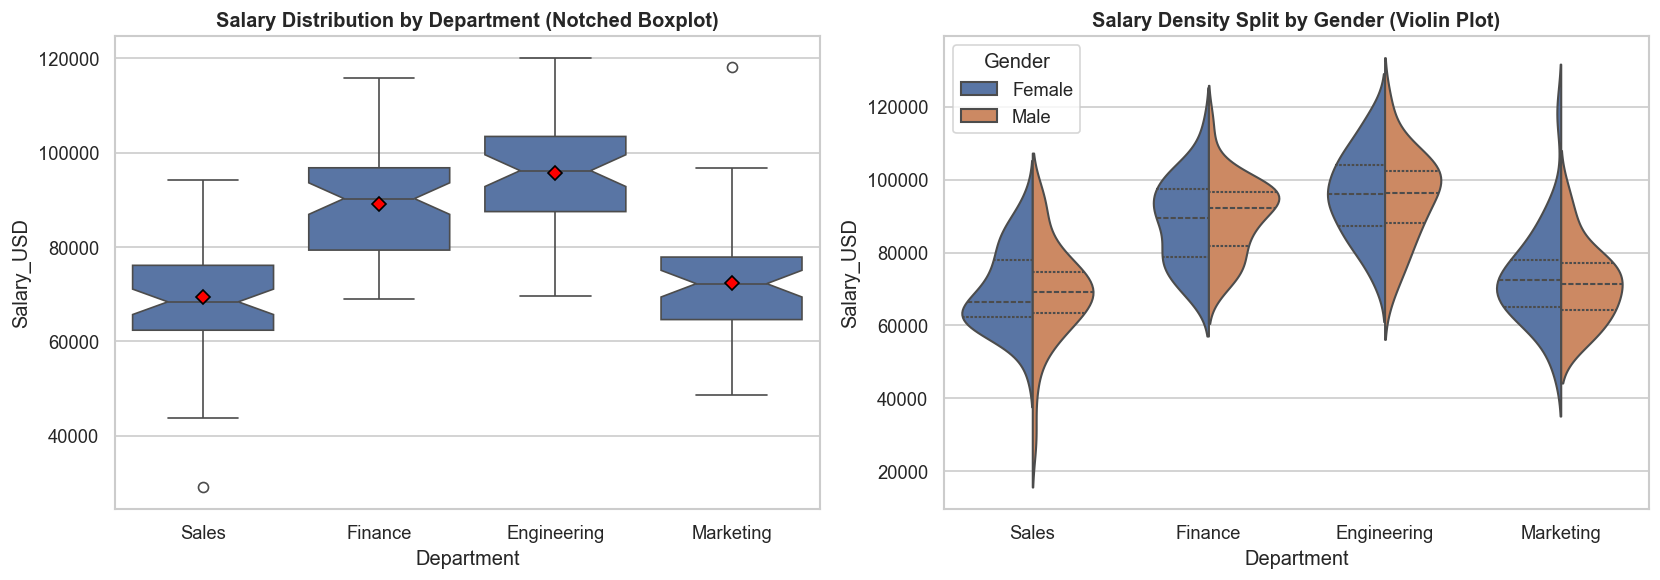

In [16]:
np.random.seed(42)
n_records = 240
depts = np.random.choice(['Engineering', 'Marketing', 'Sales', 'Finance'], n_records)
genders = np.random.choice(['Male', 'Female'], n_records)
base_sal = {'Engineering': 95000, 'Marketing': 72000, 'Sales': 68000, 'Finance': 88000}
salaries = [base_sal[d] + np.random.normal(0, 12000) for d in depts]

df_compensation = pd.DataFrame({'Department': depts, 'Gender': genders, 'Salary_USD': salaries})

# SOLUTION 8
fig8, (ax8_box, ax8_vln) = plt.subplots(1, 2, figsize=(14, 5))

# Notched Boxplot
sns.boxplot(
    data=df_compensation,
    x='Department',
    y='Salary_USD',
    notch=True,
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markeredgecolor': 'black'},
    ax=ax8_box
)
ax8_box.set_title('Salary Distribution by Department (Notched Boxplot)', fontweight='bold')

# Split Violin
sns.violinplot(
    data=df_compensation,
    x='Department',
    y='Salary_USD',
    hue='Gender',
    split=True,
    inner='quartile',
    ax=ax8_vln
)
ax8_vln.set_title('Salary Density Split by Gender (Violin Plot)', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# VERIFICATION TEST 8
assert fig8 is not None and ax8_box is not None and ax8_vln is not None, "fig8 and axes must be defined"
assert len(ax8_box.patches) >= 4 or len(ax8_box.lines) >= 4, "Boxplot elements missing"
assert len(ax8_vln.collections) >= 4, "Violin plot elements missing"
assert ax8_vln.get_legend() is not None, "Legend missing on split violin plot"

print("✅ Exercise 8 Passed!")

✅ Exercise 8 Passed!


## Exercise 9: Overlaying Jittered Stripplots on Boxplots 🎨

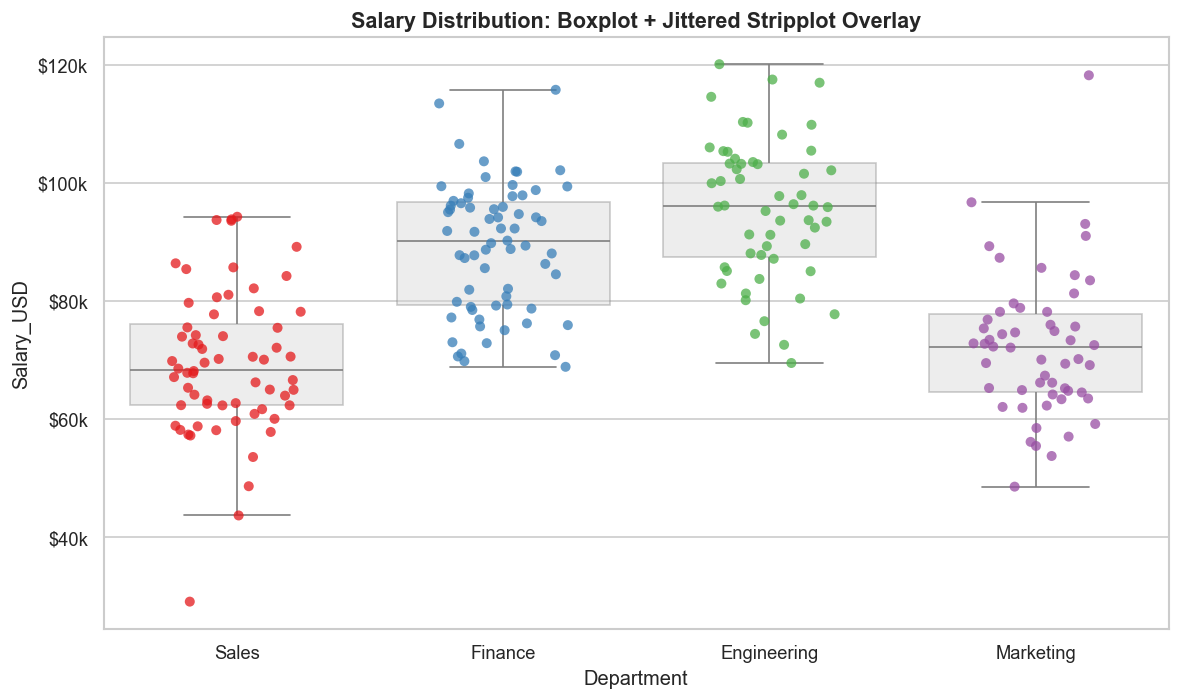

In [18]:
# SOLUTION 9
fig9, ax9 = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_compensation,
    x='Department',
    y='Salary_USD',
    color='lightgray',
    boxprops=dict(alpha=0.4),
    showfliers=False,
    ax=ax9
)

sns.stripplot(
    data=df_compensation,
    x='Department',
    y='Salary_USD',
    hue='Department',
    palette='Set1',
    size=6,
    jitter=0.25,
    alpha=0.75,
    ax=ax9
)

ax9.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f'${int(y/1000)}k'))
ax9.set_title('Salary Distribution: Boxplot + Jittered Stripplot Overlay', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# VERIFICATION TEST 9
assert fig9 is not None and ax9 is not None, "fig9 and ax9 must be defined"
assert len(ax9.collections) >= 1, "Stripplot points collection missing on ax9"
assert ax9.get_title() == 'Salary Distribution: Boxplot + Jittered Stripplot Overlay', "Title mismatch"

print("✅ Exercise 9 Passed!")

✅ Exercise 9 Passed!


## Exercise 10: Pairwise Correlation Heatmaps with Lower-Triangle Masking 🔥

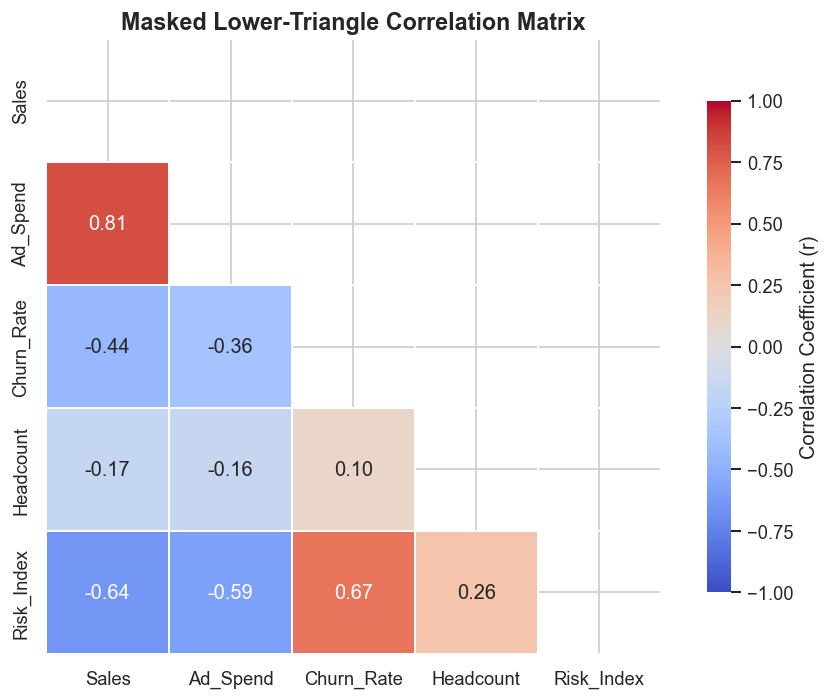

In [20]:
np.random.seed(42)
n_obs = 100
a = np.random.normal(10, 2, n_obs)
b = 0.8 * a + np.random.normal(0, 1, n_obs)
c = -0.6 * a + np.random.normal(0, 1.5, n_obs)
d = np.random.normal(50, 10, n_obs)
e = 0.5 * c - 0.4 * b + np.random.normal(0, 1, n_obs)

df_multivariate_metrics = pd.DataFrame({'Sales': a, 'Ad_Spend': b, 'Churn_Rate': c, 'Headcount': d, 'Risk_Index': e})

# SOLUTION 10
fig10, ax10 = plt.subplots(figsize=(8, 6))
corr_matrix = df_multivariate_metrics.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=1.0,
    cbar_kws={'label': 'Correlation Coefficient (r)', 'shrink': 0.8},
    ax=ax10
)
ax10.set_title('Masked Lower-Triangle Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# VERIFICATION TEST 10
assert fig10 is not None and ax10 is not None, "fig10 and ax10 must be defined"
assert corr_matrix is not None and corr_matrix.shape == (5, 5), "corr_matrix calculation error"
assert mask is not None and mask.shape == (5, 5), "mask calculation error"
assert len(ax10.collections) >= 1, "Heatmap quadmesh collection missing"
assert ax10.get_title() == 'Masked Lower-Triangle Correlation Matrix', "Title mismatch"

print("✅ Exercise 10 Passed!")

✅ Exercise 10 Passed!


## Exercise 11: Complex Multi-Panel Compositions with `plt.subplot_mosaic` 🧩

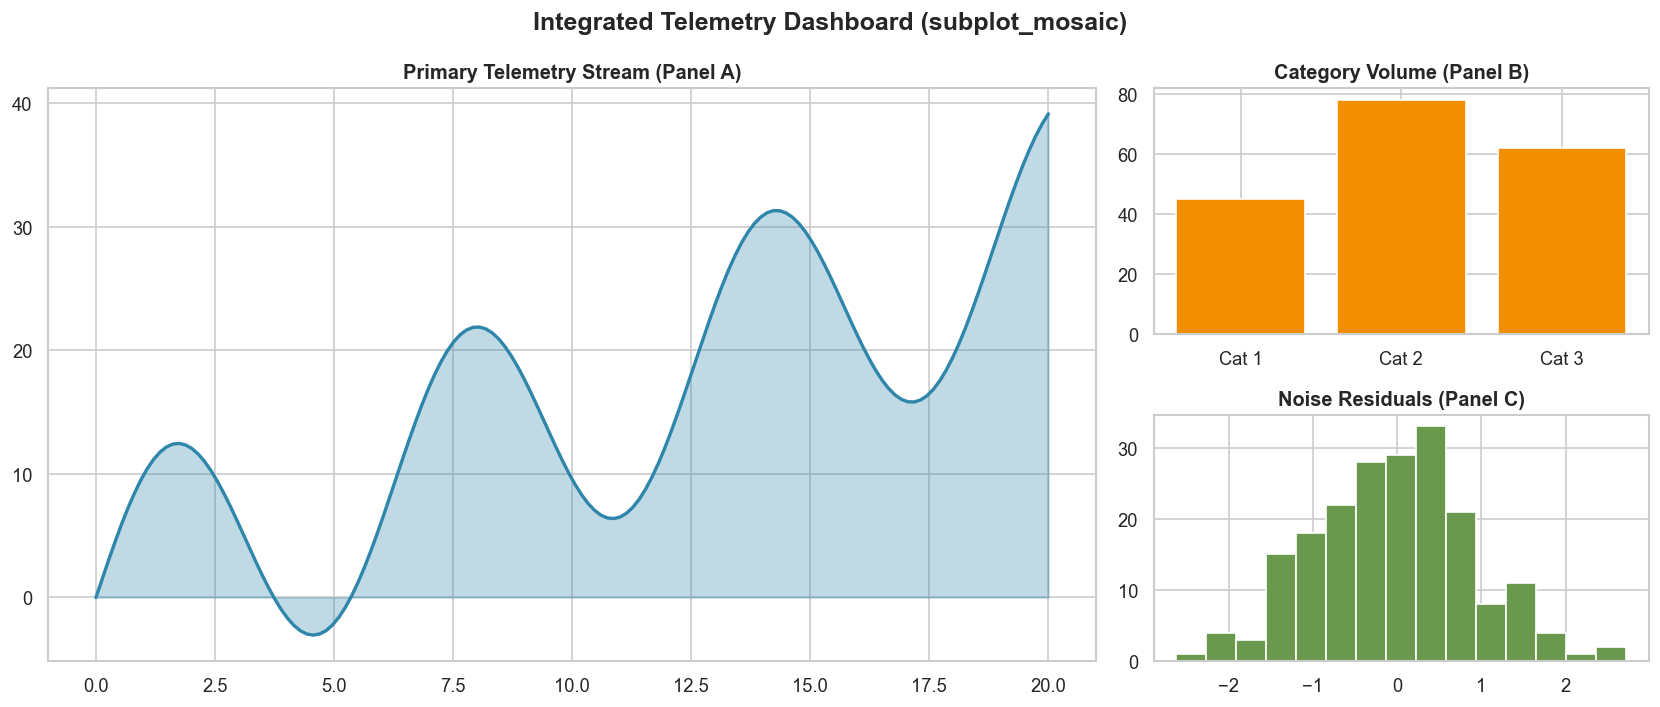

In [22]:
t = np.linspace(0, 20, 150)
signal = np.sin(t) * 10 + t * 1.5

# SOLUTION 11
layout = '''
AAB
AAC
'''
fig11, axes11 = plt.subplot_mosaic(layout, figsize=(14, 6))

# Panel A
axes11['A'].fill_between(t, signal, color='#2E86AB', alpha=0.3)
axes11['A'].plot(t, signal, color='#2E86AB', lw=2)
axes11['A'].set_title('Primary Telemetry Stream (Panel A)', fontweight='bold')

# Panel B
axes11['B'].bar(['Cat 1', 'Cat 2', 'Cat 3'], [45, 78, 62], color='#F18F01')
axes11['B'].set_title('Category Volume (Panel B)', fontweight='bold')

# Panel C
np.random.seed(42)
axes11['C'].hist(np.random.normal(0, 1, 200), bins=15, color='#6A994E', edgecolor='white')
axes11['C'].set_title('Noise Residuals (Panel C)', fontweight='bold')

fig11.suptitle('Integrated Telemetry Dashboard (subplot_mosaic)', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# VERIFICATION TEST 11
assert fig11 is not None and axes11 is not None, "fig11 and axes11 must be defined"
assert set(axes11.keys()) == {'A', 'B', 'C'}, "Mosaic keys must be 'A', 'B', 'C'"
assert len(axes11['A'].lines) >= 1, "Line missing in Panel A"
assert len(axes11['B'].patches) == 3, "Bars missing in Panel B"
assert len(axes11['C'].patches) == 15, "Histogram bins missing in Panel C"

print("✅ Exercise 11 Passed!")

✅ Exercise 11 Passed!


## Exercise 12: Dual-Axis Plots with Secondary Y-Axis (`ax.twinx`) ⚖️

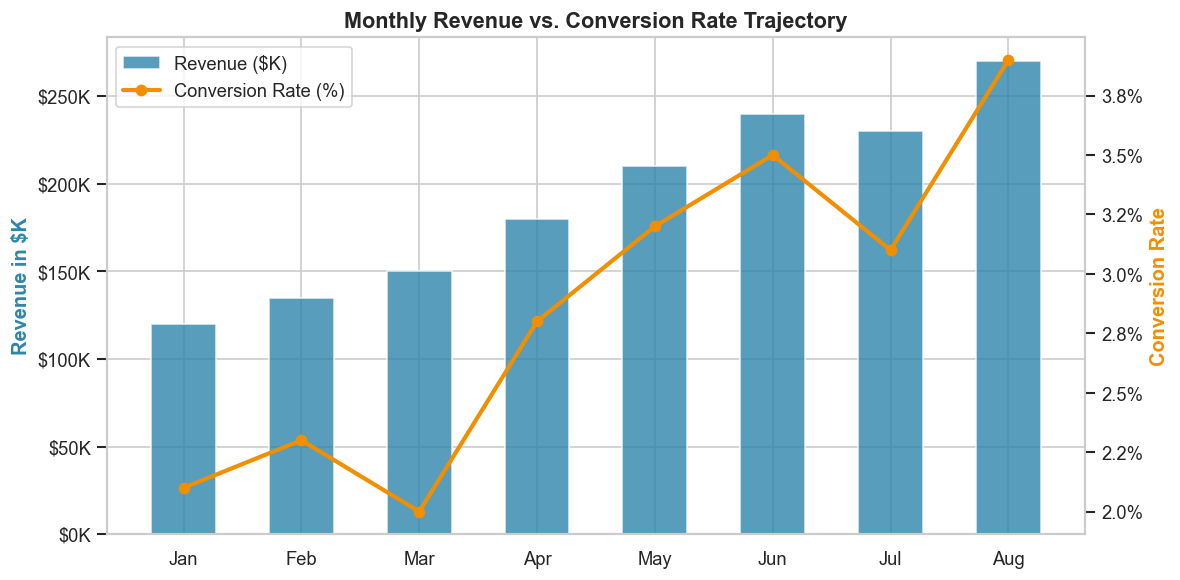

In [24]:
df_monthly_performance = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug'],
    'Revenue_K': [120, 135, 150, 180, 210, 240, 230, 270],
    'Conversion_Rate_Pct': [2.1, 2.3, 2.0, 2.8, 3.2, 3.5, 3.1, 3.9]
})

# SOLUTION 12
fig12, ax12_prim = plt.subplots(figsize=(10, 5))

# Primary Bar
bars = ax12_prim.bar(df_monthly_performance['Month'], df_monthly_performance['Revenue_K'], color='#2E86AB', alpha=0.8, width=0.55, label='Revenue ($K)')
ax12_prim.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f'${int(y)}K'))
ax12_prim.set_ylabel('Revenue in $K', color='#2E86AB', fontweight='bold')

# Secondary Line
ax12_sec = ax12_prim.twinx()
line = ax12_sec.plot(df_monthly_performance['Month'], df_monthly_performance['Conversion_Rate_Pct'], color='#F18F01', linewidth=2.5, marker='o', label='Conversion Rate (%)')
ax12_sec.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=1))
ax12_sec.set_ylabel('Conversion Rate', color='#F18F01', fontweight='bold')
ax12_sec.grid(False)

# Combined Legend
lines1, labels1 = ax12_prim.get_legend_handles_labels()
lines2, labels2 = ax12_sec.get_legend_handles_labels()
ax12_prim.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax12_prim.set_title('Monthly Revenue vs. Conversion Rate Trajectory', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# VERIFICATION TEST 12
assert fig12 is not None and ax12_prim is not None and ax12_sec is not None, "Axes must be defined"
assert len(ax12_prim.patches) == 8, f"Expected 8 bars on primary axis, got {len(ax12_prim.patches)}"
assert len(ax12_sec.lines) == 1, "Line chart missing on secondary axis"
assert ax12_prim.get_legend() is not None or ax12_sec.get_legend() is not None, "Combined legend is missing"

print("✅ Exercise 12 Passed!")

✅ Exercise 12 Passed!


## Exercise 13: Annotations, Reference Lines & Inset Zoom Plots 🔍🎯

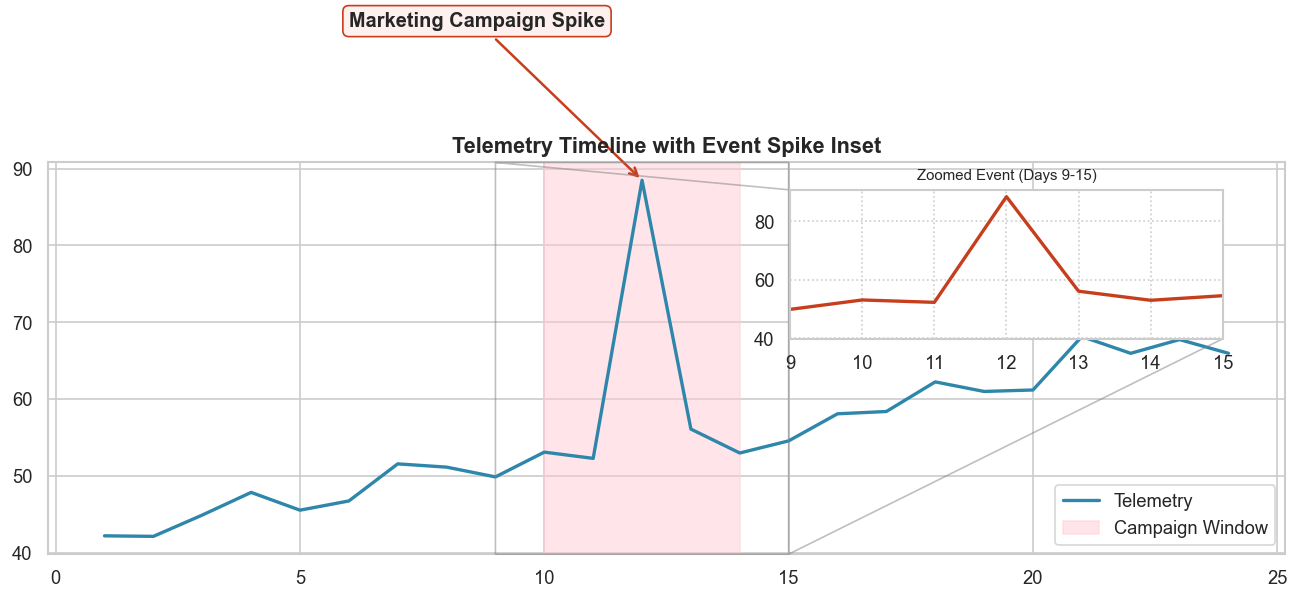

In [26]:
np.random.seed(42)
days = np.arange(1, 25)
values = 40 + 1.2 * days + np.random.normal(0, 2, 24)
values[11] += 35 # Spike on Day 12

time_series_data = pd.DataFrame({'Day': days, 'Value': values})

# SOLUTION 13
fig13, ax13 = plt.subplots(figsize=(11, 5.5))
ax13.plot(time_series_data['Day'], time_series_data['Value'], color='#2E86AB', lw=2, label='Telemetry')

# Shaded span
ax13.axvspan(10, 14, color='#FFCCD5', alpha=0.5, label='Campaign Window')

# Annotation
peak_val = time_series_data.loc[time_series_data['Day'] == 12, 'Value'].values[0]
ax13.annotate(
    'Marketing Campaign Spike',
    xy=(12, peak_val),
    xytext=(6, peak_val + 20),
    arrowprops=dict(arrowstyle="->", lw=1.5, color='#C73E1D'),
    bbox=dict(boxstyle="round,pad=0.3", fc="#FFF0F0", ec="#C73E1D"),
    fontweight='bold'
)

# Inset Zoom
ax_inset = ax13.inset_axes([0.6, 0.55, 0.35, 0.38])
ax_inset.plot(time_series_data['Day'], time_series_data['Value'], color='#C73E1D', lw=2)
ax_inset.set_xlim(9, 15)
ax_inset.set_title('Zoomed Event (Days 9-15)', fontsize=9)
ax_inset.grid(True, linestyle=':')

ax13.indicate_inset_zoom(ax_inset)
ax13.set_title('Telemetry Timeline with Event Spike Inset', fontsize=13, fontweight='bold')
ax13.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [27]:
# VERIFICATION TEST 13
assert fig13 is not None and ax13 is not None and ax_inset is not None, "fig13, ax13, ax_inset must be defined"
assert len(ax13.texts) >= 1, "Annotation text missing on primary axis"
assert len(ax13.patches) >= 1, "axvspan shading patch missing"
assert len(ax_inset.lines) >= 1, "Line plot missing in inset zoom axes"

print("✅ Exercise 13 Passed!")

✅ Exercise 13 Passed!


## Exercise 14: Donut Charts & Polar Radar Charts 🍩🧭

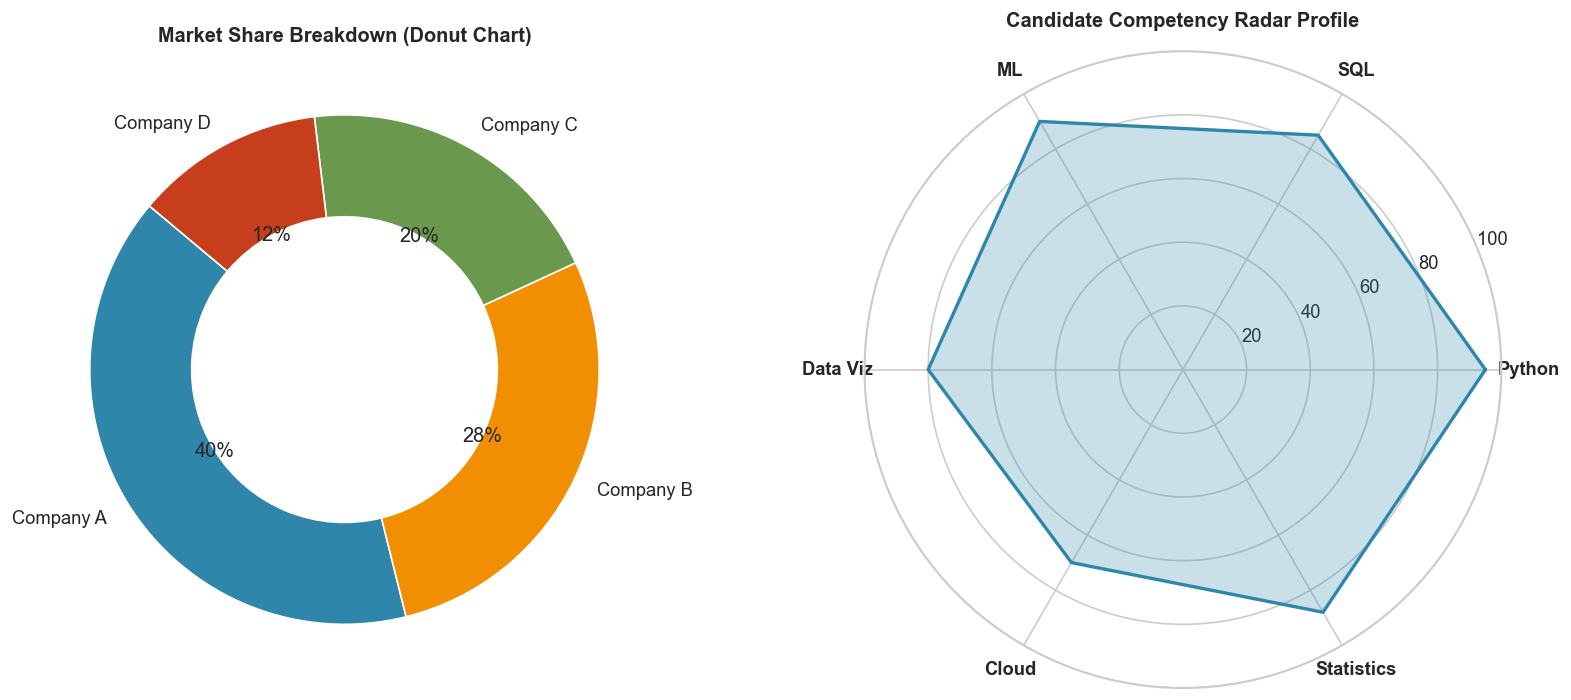

In [28]:
# Donut Data
companies = ['Company A', 'Company B', 'Company C', 'Company D']
market_shares = [40, 28, 20, 12]

# Radar Data
skills = ['Python', 'SQL', 'ML', 'Data Viz', 'Cloud', 'Statistics']
candidate_scores = [95, 85, 90, 80, 70, 88]

N = len(skills)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
candidate_scores_closed = candidate_scores + candidate_scores[:1]

# SOLUTION 14
fig14 = plt.figure(figsize=(14, 6))

# Donut
ax14_donut = fig14.add_subplot(121)
ax14_donut.pie(
    market_shares,
    labels=companies,
    autopct='%1.0f%%',
    startangle=140,
    colors=['#2E86AB', '#F18F01', '#6A994E', '#C73E1D'],
    wedgeprops=dict(width=0.4, edgecolor='white')
)
ax14_donut.set_title('Market Share Breakdown (Donut Chart)', fontweight='bold')

# Radar
ax14_radar = fig14.add_subplot(122, polar=True)
ax14_radar.plot(angles, candidate_scores_closed, color='#2E86AB', linewidth=2)
ax14_radar.fill(angles, candidate_scores_closed, color='#2E86AB', alpha=0.25)
ax14_radar.set_xticks(angles[:-1])
ax14_radar.set_xticklabels(skills, fontweight='bold')
ax14_radar.set_ylim(0, 100)
ax14_radar.set_title('Candidate Competency Radar Profile', pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# VERIFICATION TEST 14
assert fig14 is not None and ax14_donut is not None and ax14_radar is not None, "fig14, ax14_donut, ax14_radar must be defined"
assert len(ax14_donut.patches) == 4, f"Expected 4 donut wedges, got {len(ax14_donut.patches)}"
assert len(ax14_radar.lines) >= 1, "Polygon line missing on radar chart"
assert len(ax14_radar.patches) >= 1 or len(ax14_radar.collections) >= 1, "Fill polygon missing on radar chart"

print("✅ Exercise 14 Passed!")

✅ Exercise 14 Passed!


## Exercise 15: Interactive Visualizations with Plotly Express 🌐✨

In [30]:
df_tech_stocks = pd.DataFrame({
    'Company': ['Apple', 'Microsoft', 'NVIDIA', 'Amazon', 'Alphabet', 'Meta', 'Tesla', 'Adobe', 'Salesforce', 'Cisco'],
    'Sector': ['Hardware', 'Software', 'Semiconductors', 'Cloud', 'Internet', 'Internet', 'Auto/AI', 'Software', 'Software', 'Networking'],
    'Sub_Industry': ['Consumer Electronics', 'Enterprise OS', 'GPU Chips', 'E-Commerce', 'Search', 'Social Media', 'EV', 'Design Tools', 'CRM', 'Hardware'],
    'Market_Cap_B': [3100, 3050, 2900, 1950, 2100, 1250, 680, 230, 270, 190],
    'Revenue_B': [385, 235, 80, 575, 305, 135, 95, 20, 35, 57],
    'Employees': [160000, 220000, 30000, 1500000, 180000, 70000, 140000, 30000, 75000, 85000]
})

# SOLUTION 15
fig_scatter = px.scatter(
    df_tech_stocks,
    x='Market_Cap_B',
    y='Revenue_B',
    color='Sector',
    size='Employees',
    hover_name='Company',
    title='Tech Enterprise: Market Cap vs. Revenue ($B)'
)

fig_sunburst = px.sunburst(
    df_tech_stocks,
    path=['Sector', 'Sub_Industry', 'Company'],
    values='Market_Cap_B',
    title='Hierarchical Market Cap Drilldown'
)

fig_scatter.show()
fig_sunburst.show()

In [31]:
# VERIFICATION TEST 15
assert fig_scatter is not None, "fig_scatter is not defined"
assert fig_sunburst is not None, "fig_sunburst is not defined"
assert len(fig_scatter.data) >= 1, "Data traces missing in fig_scatter"
assert len(fig_sunburst.data) >= 1, "Data traces missing in fig_sunburst"

print("✅ Exercise 15 Passed!")

✅ Exercise 15 Passed!


## Exercise 16: Comprehensive Real-World Visual Analytics Capstone Dashboard 🏆📈

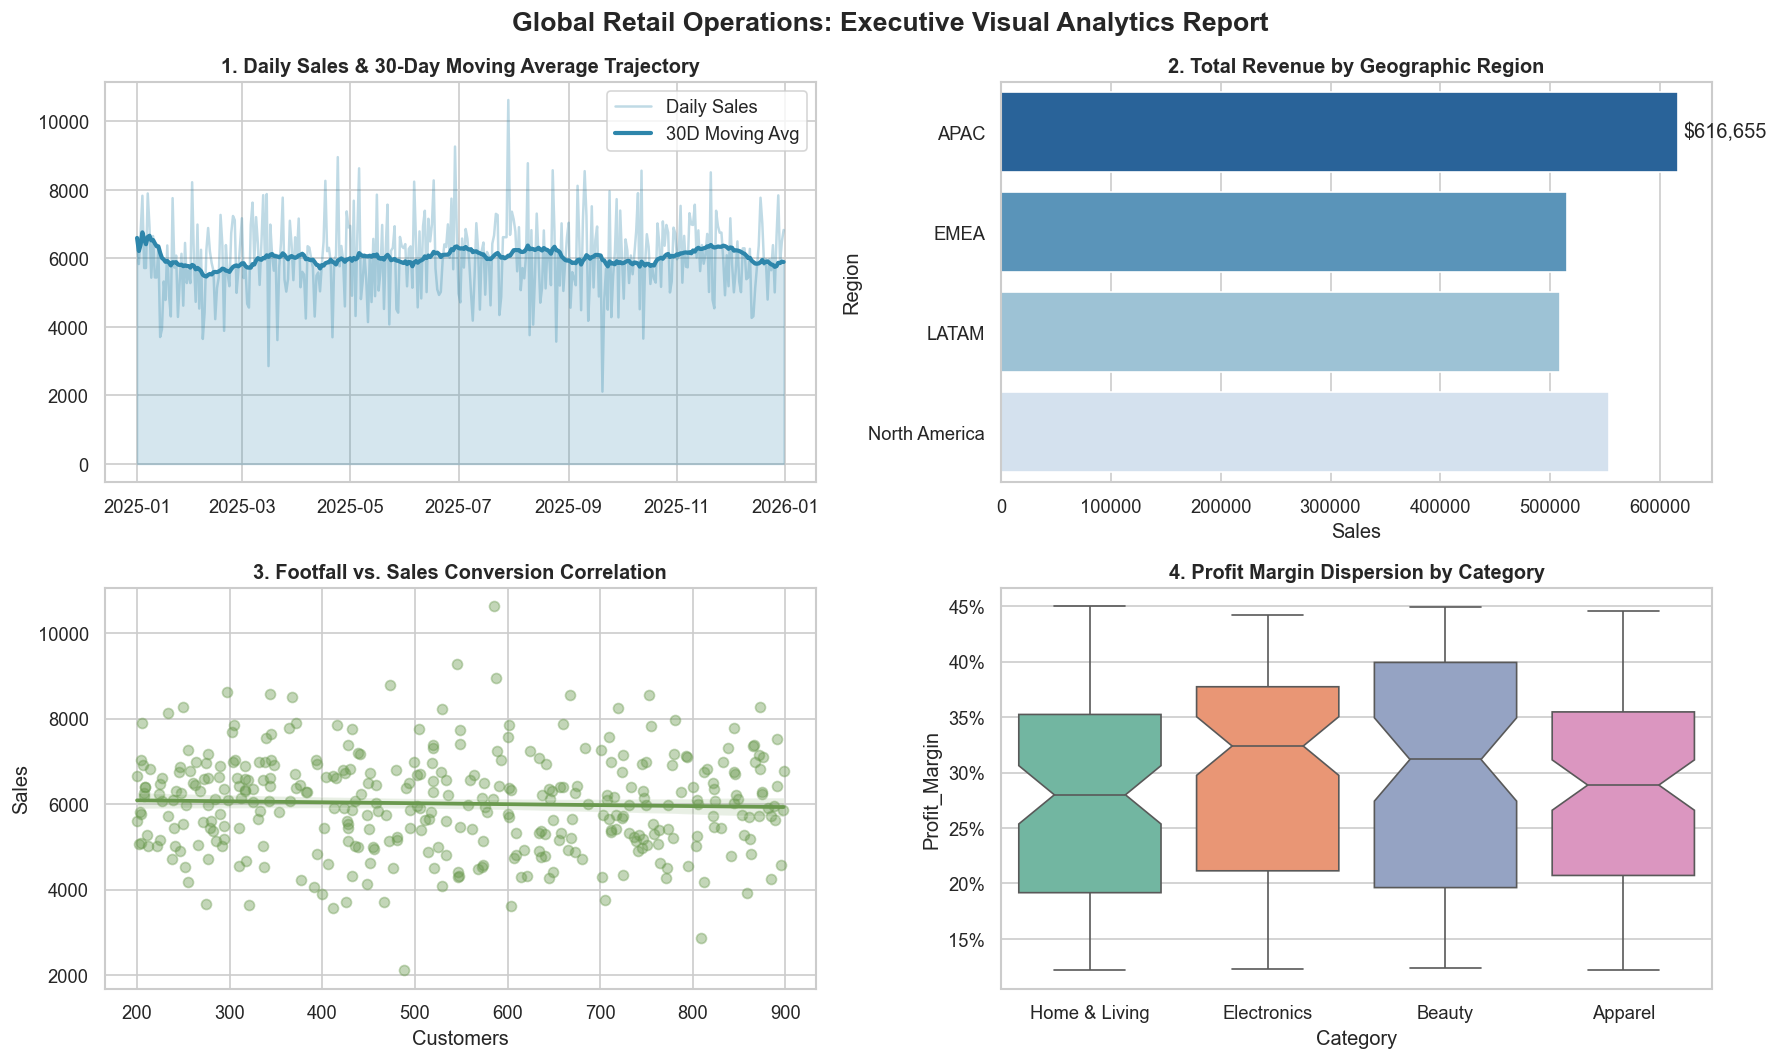

In [32]:
np.random.seed(42)
dates = pd.date_range('2025-01-01', '2025-12-31', freq='D')
n_days = len(dates)

df_capstone_sales = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.normal(6000, 1200, n_days).clip(1000),
    'Customers': np.random.randint(200, 900, n_days),
    'Region': np.random.choice(['North America', 'EMEA', 'APAC', 'LATAM'], n_days),
    'Category': np.random.choice(['Apparel', 'Electronics', 'Home & Living', 'Beauty'], n_days),
    'Profit_Margin': np.random.uniform(0.12, 0.45, n_days)
})
df_capstone_sales['Sales_30D_MA'] = df_capstone_sales['Sales'].rolling(window=30, min_periods=1).mean()

# SOLUTION 16 (CAPSTONE)
dashboard_layout = '''
AABB
CCDD
'''
fig_capstone, axes_capstone = plt.subplot_mosaic(dashboard_layout, figsize=(15, 9))

# Panel A: Time Series
axes_capstone['A'].plot(df_capstone_sales['Date'], df_capstone_sales['Sales'], color='#2E86AB', alpha=0.3, label='Daily Sales')
axes_capstone['A'].plot(df_capstone_sales['Date'], df_capstone_sales['Sales_30D_MA'], color='#2E86AB', lw=2.5, label='30D Moving Avg')
axes_capstone['A'].fill_between(df_capstone_sales['Date'], df_capstone_sales['Sales_30D_MA'], alpha=0.2, color='#2E86AB')
axes_capstone['A'].set_title('1. Daily Sales & 30-Day Moving Average Trajectory', fontweight='bold')
axes_capstone['A'].legend()

# Panel B: Regional Revenue
region_summary = df_capstone_sales.groupby('Region')['Sales'].sum().reset_index()
bars_b = sns.barplot(data=region_summary, y='Region', x='Sales', palette='Blues_r', ax=axes_capstone['B'])
axes_capstone['B'].bar_label(bars_b.containers[0], fmt='${:,.0f}', padding=3)
axes_capstone['B'].set_title('2. Total Revenue by Geographic Region', fontweight='bold')

# Panel C: Customer Footfall vs Sales Correlation
sns.regplot(data=df_capstone_sales, x='Customers', y='Sales', color='#6A994E', scatter_kws={'alpha': 0.4}, ax=axes_capstone['C'])
axes_capstone['C'].set_title('3. Footfall vs. Sales Conversion Correlation', fontweight='bold')

# Panel D: Profit Margin by Category
sns.boxplot(data=df_capstone_sales, x='Category', y='Profit_Margin', palette='Set2', notch=True, ax=axes_capstone['D'])
axes_capstone['D'].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
axes_capstone['D'].set_title('4. Profit Margin Dispersion by Category', fontweight='bold')

fig_capstone.suptitle('Global Retail Operations: Executive Visual Analytics Report', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
# VERIFICATION TEST 16 (CAPSTONE)
assert fig_capstone is not None and axes_capstone is not None, "fig_capstone and axes_capstone must be defined"
assert set(axes_capstone.keys()) == {'A', 'B', 'C', 'D'}, "Dashboard panels A, B, C, D must be present"
assert len(axes_capstone['A'].lines) >= 1, "Time series plot missing in Panel A"
assert len(axes_capstone['B'].patches) >= 4, "Regional bars missing in Panel B"
assert len(axes_capstone['C'].collections) >= 1, "Scatter points missing in Panel C"
assert len(axes_capstone['D'].patches) >= 4 or len(axes_capstone['D'].lines) >= 4, "Boxplot elements missing in Panel D"

print("🎉 CONGRATULATIONS! You have completed all exercises and the Visual Analytics Capstone Dashboard! 🚀")

🎉 CONGRATULATIONS! You have completed all exercises and the Visual Analytics Capstone Dashboard! 🚀
